  Day Outlook  Temp Humidity    Wind
0  D1     Sun   Hot     High    Weak
1  D2     Sun   Hot     High  Strong
2  D3   Cloud   Hot     High    Weak
3  D4    Rain  Mild     High    Weak
4  D5    Rain  Cool   Normal    Weak
   Day_D1  Day_D10  Day_D11  Day_D12  Day_D13  Day_D14  Day_D2  Day_D3  \
0    True    False    False    False    False    False   False   False   
1   False    False    False    False    False    False    True   False   
2   False    False    False    False    False    False   False    True   
3   False    False    False    False    False    False   False   False   
4   False    False    False    False    False    False   False   False   

   Day_D4  Day_D5  ...  Outlook_Cloud  Outlook_Rain  Outlook_Sun  Temp_Cool  \
0   False   False  ...          False         False         True      False   
1   False   False  ...          False         False         True      False   
2   False   False  ...           True         False        False      False   
3    True   False

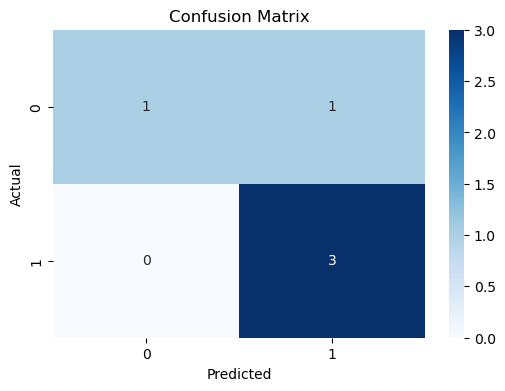

F1 Score: 0.7810


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 讀取資料
data = pd.read_csv("weather_data.csv")

# 2. 資料前處理
# 假設目標欄位名稱為 'Tennis'，其他欄位皆作為特徵
# 若資料中有非數值型特徵，可採用 get_dummies 或其他編碼方式轉換
target_column = 'Tennis'
X = data.drop(columns=[target_column])
y = data[target_column]
print(X.head())

# 若特徵中包含類別資料，使用 one-hot encoding
X = pd.get_dummies(X)
print(X.head())
# 若目標變數為類別型，進行編碼
le = LabelEncoder()
y = le.fit_transform(y)

# 3. 切分資料為訓練集與測試集 (例如 70% 訓練, 30% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. 建立並訓練 Gaussian Naive Bayes 模型
model = GaussianNB()
model.fit(X_train, y_train)

# 5. 模型預測
y_pred = model.predict(X_test)

# 6. 評估：混淆矩陣
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 繪製混淆矩陣
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 7. 評估：F1-score (weighted 平均以考慮各類別樣本比例)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score: {:.4f}".format(f1))
